# Student Performance Factors Data Exploration
**Research question:** Which factors have the greatest influence on student exam performance?

## Block 1 Load & First Look

In [1]:
import pandas as pd # To read the data
import matplotlib.pyplot as plt # To visualize the data
import seaborn as sns # To visualize the data

df = pd.read_csv('../../data/data_cleaned.csv') # THE Data gets read and storaged in the variable df

print(f'Rows:    {df.shape[0]}') # df.shape[0] gives the rows
print(f'Columns: {df.shape[1]}') # df.shape[1] gives the columns
print() # creating space for beetter reading
print('Column names and data types:')
print(df.dtypes) # df.dtypes gives the data types of each column
print()
print('First 5 rows:')
df.head() # df.head is a special funtion that shwos the first 5 of the data set

Rows:    6378
Columns: 20

Column names and data types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

First 5 rows:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## Block 2 Basic Stats

In [2]:
print('Basic statistics for numeric columns:')
df.describe().round(2) # df.describe() shows some basic statistics only for int64 and float and with round 2 it rounds the numbers in 2 decimal

Basic statistics for numeric columns:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6378.00,6378.00,6378.00,6378.00,6378.00,6378.00,6378.00
mean,19.98,80.02,7.03,75.07,1.50,2.97,67.25
std,5.99,11.55,1.47,14.40,1.23,1.03,3.91
min,1.00,60.00,4.00,50.00,0.00,0.00,55.00
25%,16.00,70.00,6.00,63.00,1.00,2.00,65.00
50%,20.00,80.00,7.00,75.00,1.00,3.00,67.00
75%,24.00,90.00,8.00,88.00,2.00,4.00,69.00
max,44.00,100.00,10.00,100.00,8.00,6.00,101.00


## Block 3 Missing Values

In [3]:
missing = df.isnull().sum() # these 2 variable are here for to count the nan and empty values
empty = (df == '').sum()
total_missing = (missing + empty).sort_values(ascending=False)
total_missing = total_missing[total_missing > 0] #and with this only the ones wich have nan or empty are shwon

print('Columns with missing or empty values:')
for col, count in total_missing.items(): # this loop is for to print the columns with missing values and how many they are
    print(f'  {col}: {count} missing')

print()
print('Dropping rows with missing values')
df = df.replace('', pd.NA).dropna() # drops every row with empty values and nan values
print(f'Rows after cleaning: {len(df)}')

df.to_csv('../../data/data_cleaned.csv', index=False) # saves the cleaned data to a new csv file without the index
print('Saved to data/data_cleaned.csv')

Columns with missing or empty values:

Dropping rows with missing values
Rows after cleaning: 6378
Saved to data/data_cleaned.csv


## Block 4 Category Overview

In [4]:
categorical_cols = df.select_dtypes(include='object').columns # this line is for to select only the columns with the data type object which are the categorical columns

for col in categorical_cols: # this loop is for to print the value counts of each categorical column
    print(f'{col}:')
    counts = df[col].value_counts() # df[col].value_counts() gives the count of each unique value in the column
    for val, count in counts.items(): # this loop is for to print the value and the count of each unique value in the column
        pct = count / len(df)
        print(f'  {val}: {count}')
    print()

Parental_Involvement:
  Medium: 3251
  High: 1836
  Low: 1291

Access_to_Resources:
  Medium: 3204
  High: 1900
  Low: 1274

Extracurricular_Activities:
  Yes: 3807
  No: 2571

Motivation_Level:
  Medium: 3237
  Low: 1864
  High: 1277

Internet_Access:
  Yes: 5893
  No: 485

Family_Income:
  Low: 2582
  Medium: 2566
  High: 1230

Teacher_Quality:
  Medium: 3826
  High: 1905
  Low: 647

School_Type:
  Public: 4434
  Private: 1944

Peer_Influence:
  Positive: 2553
  Neutral: 2495
  Negative: 1330

Learning_Disabilities:
  No: 5710
  Yes: 668

Parental_Education_Level:
  High School: 3159
  College: 1939
  Postgraduate: 1280

Distance_from_Home:
  Near: 3801
  Moderate: 1941
  Far: 636

Gender:
  Male: 3688
  Female: 2690



## Block 5 First Look at Exam Score

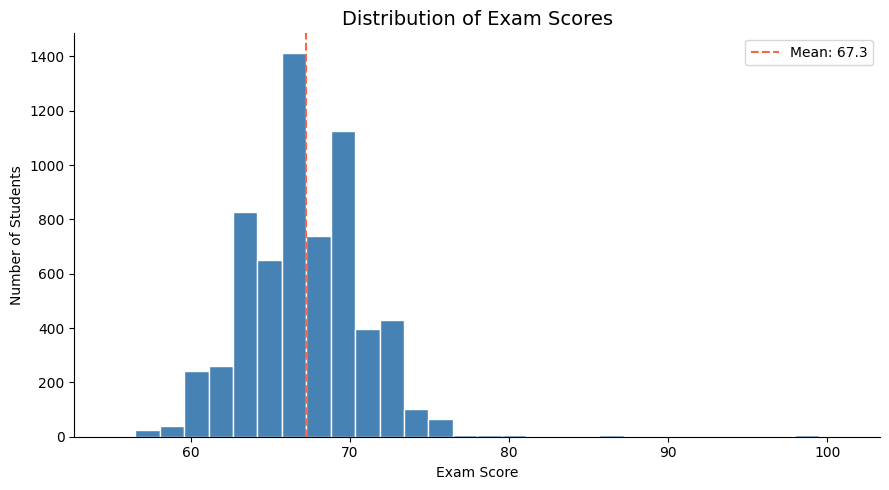

Mean:   67.25
Median: 67.00
Min:    55
Max:    101


In [5]:
fig, ax = plt.subplots(figsize=(9, 5)) # Grösse der Grafik

ax.hist(df['Exam_Score'], bins=30, color='steelblue', edgecolor='white')# Histogramm with Exam_Score variabel, 30 bin for the bars 

ax.axvline(df['Exam_Score'].mean(), color='tomato', linestyle='--', linewidth=1.5, #for the mean line in the histogram
           label=f"Mean: {df['Exam_Score'].mean():.1f}")

ax.set_title('Distribution of Exam Scores', fontsize=14)# Title of the histogram and its specification with x and y label and legend
ax.set_xlabel('Exam Score')
ax.set_ylabel('Number of Students')
ax.legend()
sns.despine()

plt.tight_layout()
plt.show()

print(f"Mean:   {df['Exam_Score'].mean():.2f}")
print(f"Median: {df['Exam_Score'].median():.2f}")
print(f"Min:    {df['Exam_Score'].min()}")
print(f"Max:    {df['Exam_Score'].max()}")

## Block 6: Correlation with Exam Score

To decide which factors are worth investigating further, we calculate the Pearson correlation of every variable with `Exam_Score`.

Categorical variables (e.g. `Motivation_Level`: Low/Medium/High) are encoded as ordinal numbers before computing the correlation.

This gives us a clear ranking of which factors have the strongest relationship with exam performance, and directly informs the choice of sub-topics for the visualization project.

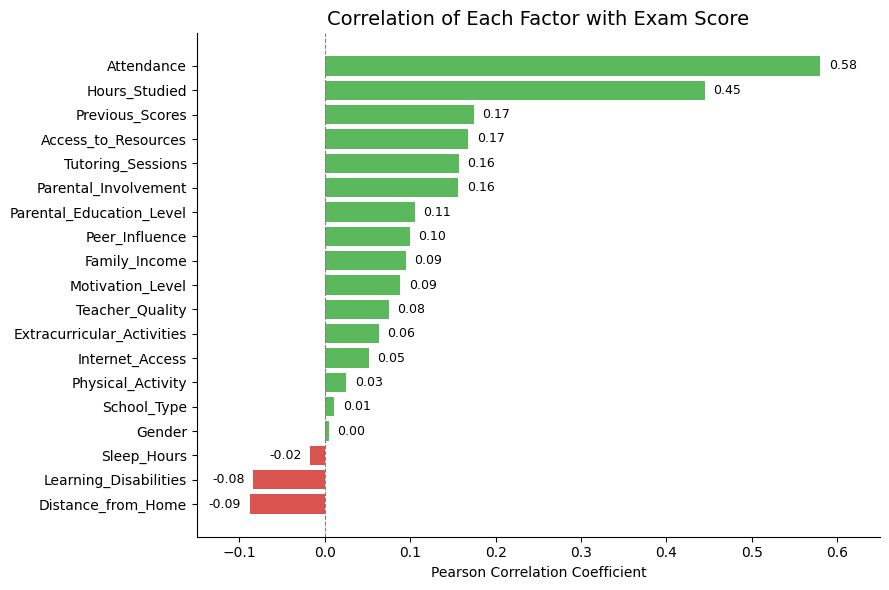

In [6]:
df_encoded = df.copy() # we need to encode the categorical variables to calculate the correlation, so we create a copy of the original dataframe to do that

cat_map = { # putting categorial in numerical values for correlation
    'Low': 1, 'Medium': 2, 'High': 3,
    'No': 0, 'Yes': 1,
    'Public': 0, 'Private': 1,
    'Negative': 1, 'Neutral': 2, 'Positive': 3,
    'Male': 0, 'Female': 1,
    'Near': 1, 'Moderate': 2, 'Far': 3,
    'High School': 1, 'College': 2, 'Postgraduate': 3
}
for col in df_encoded.select_dtypes(include='object').columns: # Creation of the correlation
    df_encoded[col] = df_encoded[col].map(cat_map)

corr = df_encoded.corr()['Exam_Score'].drop('Exam_Score').sort_values() # Creation of correlation with variabel Exam_Score, dropping itself because ist obviously 1 and sorting the values
colors = ['#d9534f' if v < 0 else '#5cb85c' for v in corr]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(corr.index, corr.values, color=colors) # creating a horizontal bar chart with the correlation values and coloring them red for negative and green for positive
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Correlation of Each Factor with Exam Score', fontsize=14)
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_xlim(-0.15, 0.65)

for bar, val in zip(bars, corr.values): # this loop is for to add the correlation values at the end of each bar, with a little offset for better visibility 
    ax.text(val + 0.01 if val >= 0 else val - 0.01, # WRITE TEXT ON BALKS
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}',
            va='center', ha='left' if val >= 0 else 'right', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

### Interpretation

- **Attendance** shows the strongest positive correlation with Exam Score, students who attend more consistently tend to score higher.
- **Hours_Studied** also has a meaningful positive correlation, confirming that study time matters.
- **Previous_Scores** shows almost no correlation, past performance does not predict current exam results in this dataset.
- Social and motivational factors like **Family_Income**, **Parental_Involvement**, and **Motivation_Level** show small but positive correlations and will be explored in the visualization phase.
- No variable shows a strong negative correlation with Exam Score.

# Student Performance Factors Visualizations

## Sub-topic 1 Learning Habits
Motivation: The correlation analysis showed that Attendance (0.58) and Hours_Studied (0.45) are the two strongest predictors of exam performance. This sub-topic explores these relationships in detail.

Chart 1: Scatterplot; Attendance vs Exam_Score
Chart 2: Scatterplot; Hours_Studied vs Exam_Score
Interpretation: What patterns do we see? Do they confirm the correlation?

## Sub-topic 2 Social & Family Factors
Motivation: Family_Income, Parental_Involvement, and Access_to_Resources all showed small but positive correlations. This sub-topic asks: does socioeconomic background play a role?

Chart 3: Bar chart; avg Exam_Score by Family_Income
Chart 4: Bar chart; avg Exam_Score by Parental_Involvement
Interpretation: Are the differences meaningful despite the low correlation?

## Sub-topic 3 Personal & Motivational Factors
Motivation: Motivation_Level and Peer_Influence showed low-to-moderate correlations. This sub-topic checks whether attitude and social environment matter.

Chart 5: Boxplot; Exam_Score by Motivation_Level
Chart 6: Boxplot; Exam_Score by Peer_Influence
Interpretation: Does higher motivation consistently lead to higher scores?